In [1]:
# ══════════════════════════════════════════════════════════════════
# FAKE NEWS CLASSIFIER — Full Pipeline
# ══════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import json, re, os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score)
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# ══════════════════════════════════════════════════════════════════
# 1. LOAD DATA
# ══════════════════════════════════════════════════════════════════

df  = pd.read_csv("dataset/data.csv")
val = pd.read_csv("dataset/validation_data.csv")

print("── Training data ──────────────────────────")
print(df.shape)
print(df["label"].value_counts())
print(df.head(3))

print("\n── Validation data ────────────────────────")
print(val.shape)
print(val["label"].value_counts())   # should be all 2s
print(val.head(3))


── Training data ──────────────────────────
(39942, 5)
label
1    19999
0    19943
Name: count, dtype: int64
   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The special counsel inv...  politicsNews   

                 date  
0  December 31, 2017   
1  December 29, 2017   
2  December 31, 2017   

── Validation data ────────────────────────
(4956, 5)
label
2    4956
Name: count, dtype: int64


── Shape ───────────────────────────────────
(39942, 5)

── Data Types ──────────────────────────────
label       int64
title      object
text       object
subject    object
date       object
dtype: object

── Missing Values ──────────────────────────
label      0
title      0
text       0
subject    0
date       0
dtype: int64

── Sample Rows ─────────────────────────────
   label                                              title  \
0      1  As U.S. budget fight looms, Republicans flip t...   
1      1  U.S. military to accept transgender recruits o...   
2      1  Senior U.S. Republican senator: 'Let Mr. Muell...   
3      1  FBI Russia probe helped by Australian diplomat...   
4      1  Trump wants Postal Service to charge 'much mor...   

                                                text       subject  \
0  WASHINGTON (Reuters) - The head of a conservat...  politicsNews   
1  WASHINGTON (Reuters) - Transgender people will...  politicsNews   
2  WASHINGTON (Reuters) - The speci

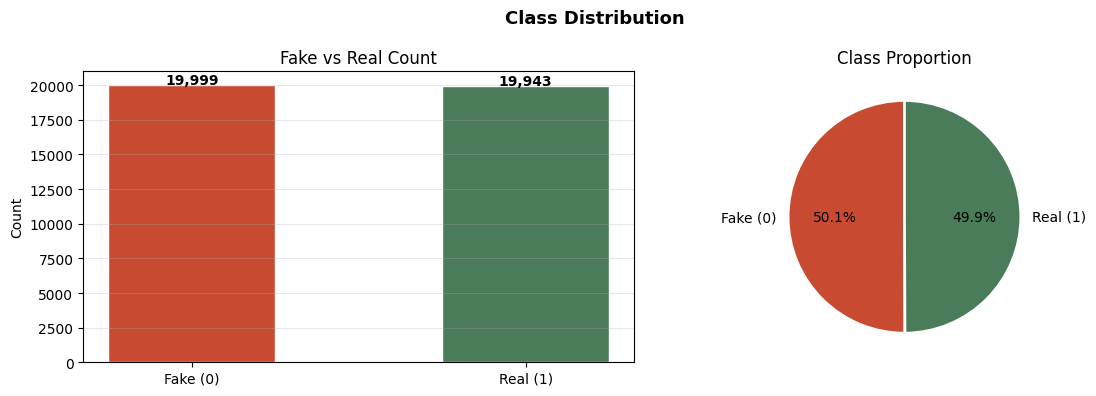

In [17]:
# ══════════════════════════════════════════════════════════════════
# 1. BASIC INFO
# ══════════════════════════════════════════════════════════════════

print("── Shape ───────────────────────────────────")
print(df.shape)

print("\n── Data Types ──────────────────────────────")
print(df.dtypes)

print("\n── Missing Values ──────────────────────────")
print(df.isnull().sum())

print("\n── Sample Rows ─────────────────────────────")
print(df.head(5))

print("\n── Label Distribution ──────────────────────")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).mul(100).round(2).astype(str) + "%")

# ══════════════════════════════════════════════════════════════════
# 2. CLASS BALANCE
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution", fontsize=13, fontweight="bold")

# Count plot
counts = df["label"].value_counts()
colors = ["#c84b31", "#4a7c59"]
axes[0].bar(["Fake (0)", "Real (1)"], counts.values, color=colors, edgecolor="white", width=0.5)
axes[0].set_ylabel("Count")
axes[0].set_title("Fake vs Real Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].grid(axis="y", alpha=0.3)

# Pie chart
axes[1].pie(counts.values, labels=["Fake (0)", "Real (1)"],
            colors=colors, autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Class Proportion")

plt.tight_layout()
plt.savefig("results/eda_class_balance.png", dpi=150, bbox_inches="tight")
plt.show()



── Title Length (words) ────────────────────
         count  mean  std  min   25%   50%   75%   max
label                                                 
0      19943.0  14.8  4.2  1.0  12.0  14.0  17.0  42.0
1      19999.0   9.9  1.7  4.0   9.0  10.0  11.0  20.0

── Text Length (words) ─────────────────────
         count   mean    std  min    25%    50%    75%     max
label                                                         
0      19943.0  396.9  296.7  0.0  252.0  366.0  495.0  7033.0
1      19999.0  386.5  275.6  0.0  146.0  361.0  527.0  5172.0


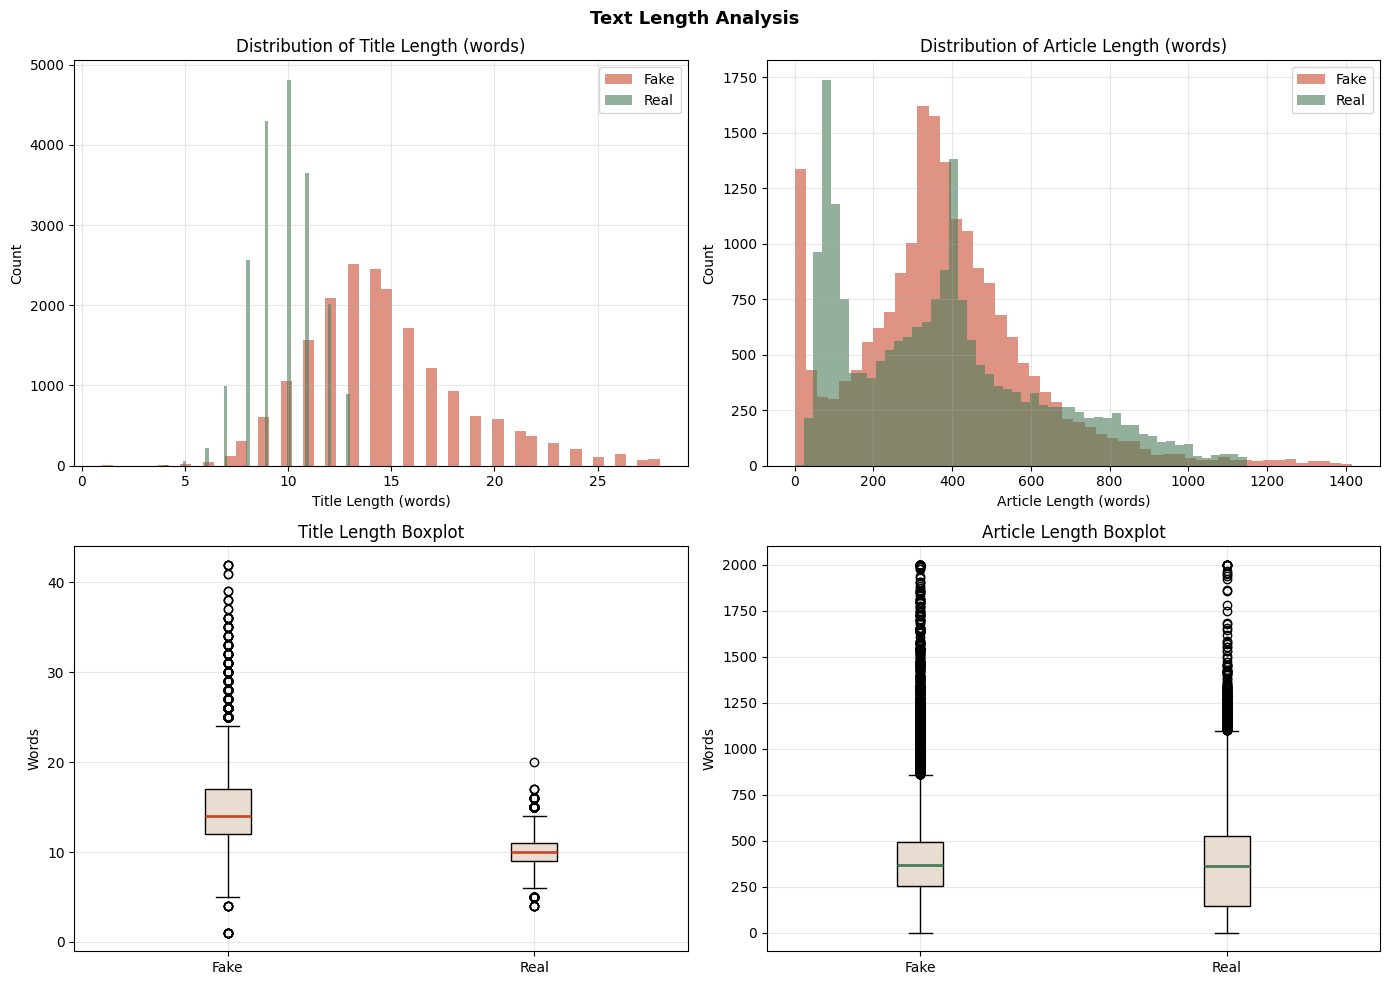


── Subjects ────────────────────────────────
subject
politicsNews       11272
News                9050
worldnews           8727
politics            6841
left-news           2482
Government News     1570
Name: count, dtype: int64


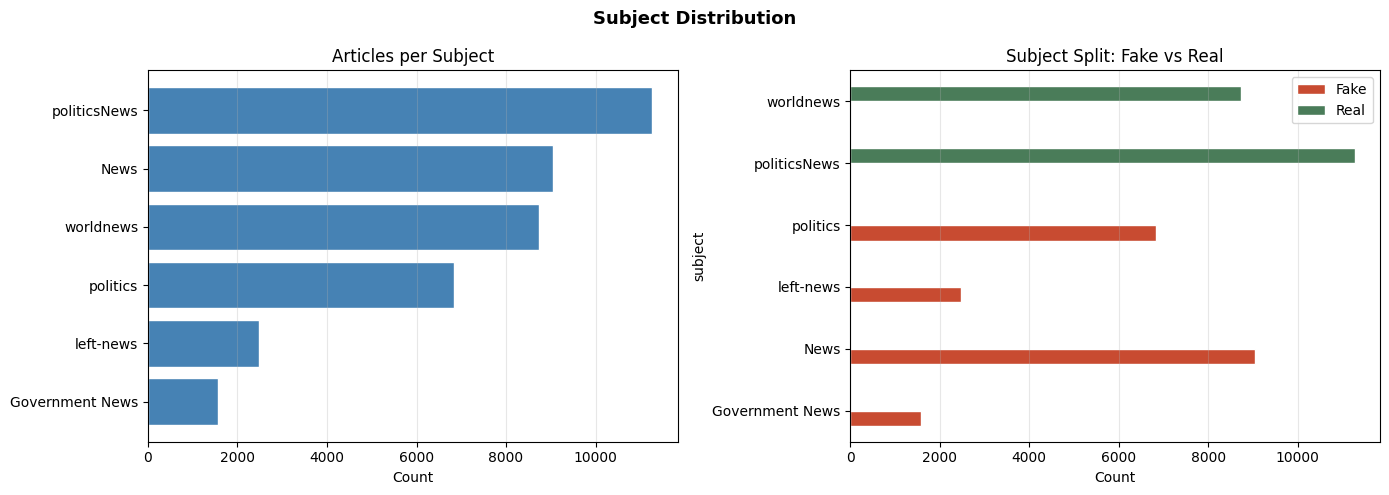

In [18]:
# ══════════════════════════════════════════════════════════════════
# 3. TEXT LENGTH ANALYSIS
# ══════════════════════════════════════════════════════════════════

df["title_len"]   = df["title"].fillna("").apply(lambda x: len(x.split()))
df["text_len"]    = df["text"].fillna("").apply(lambda x: len(x.split()))
df["title_chars"] = df["title"].fillna("").apply(len)

print("\n── Title Length (words) ────────────────────")
print(df.groupby("label")["title_len"].describe().round(1))

print("\n── Text Length (words) ─────────────────────")
print(df.groupby("label")["text_len"].describe().round(1))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Text Length Analysis", fontsize=13, fontweight="bold")

for ax, (col, title) in zip(axes.flatten(), [
    ("title_len",  "Title Length (words)"),
    ("text_len",   "Article Length (words)"),
]):
    for label, color, name in [(0, "#c84b31", "Fake"), (1, "#4a7c59", "Real")]:
        data = df[df["label"] == label][col]
        data = data[data < data.quantile(0.99)]  # remove extreme outliers for display
        ax.hist(data, bins=50, alpha=0.6, color=color, label=name, edgecolor="none")
    ax.set_xlabel(title); ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {title}")
    ax.legend(); ax.grid(alpha=0.3)

# Box plots
axes[1][0].boxplot(
    [df[df["label"]==0]["title_len"].clip(upper=50),
     df[df["label"]==1]["title_len"].clip(upper=50)],
    labels=["Fake", "Real"], patch_artist=True,
    boxprops=dict(facecolor="#e8ddd0"),
    medianprops=dict(color="#c84b31", linewidth=2)
)
axes[1][0].set_title("Title Length Boxplot"); axes[1][0].set_ylabel("Words")
axes[1][0].grid(alpha=0.3)

axes[1][1].boxplot(
    [df[df["label"]==0]["text_len"].clip(upper=2000),
     df[df["label"]==1]["text_len"].clip(upper=2000)],
    labels=["Fake", "Real"], patch_artist=True,
    boxprops=dict(facecolor="#e8ddd0"),
    medianprops=dict(color="#4a7c59", linewidth=2)
)
axes[1][1].set_title("Article Length Boxplot"); axes[1][1].set_ylabel("Words")
axes[1][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("results/eda_text_length.png", dpi=150, bbox_inches="tight")
plt.show()

# ══════════════════════════════════════════════════════════════════
# 4. SUBJECT / CATEGORY ANALYSIS
# ══════════════════════════════════════════════════════════════════

if "subject" in df.columns:
    print("\n── Subjects ────────────────────────────────")
    print(df["subject"].value_counts())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Subject Distribution", fontsize=13, fontweight="bold")

    # Overall subject counts
    subj_counts = df["subject"].value_counts()
    axes[0].barh(subj_counts.index[::-1], subj_counts.values[::-1],
                 color="steelblue", edgecolor="white")
    axes[0].set_title("Articles per Subject")
    axes[0].set_xlabel("Count")
    axes[0].grid(axis="x", alpha=0.3)

    # Subject split by fake vs real
    subj_label = df.groupby(["subject", "label"]).size().unstack(fill_value=0)
    subj_label.columns = ["Fake", "Real"]
    subj_label.plot(kind="barh", ax=axes[1], color=["#c84b31", "#4a7c59"],
                    edgecolor="white")
    axes[1].set_title("Subject Split: Fake vs Real")
    axes[1].set_xlabel("Count")
    axes[1].legend()
    axes[1].grid(axis="x", alpha=0.3)

    plt.tight_layout()
    plt.savefig("results/eda_subjects.png", dpi=150, bbox_inches="tight")
    plt.show()